In [4]:
# Course section: Classification
# Dataset: Sleep Health and Lifestyle
# Goal: Use a Random Forest Classifier to predict Sleep Disorder (None / Insomnia / Sleep Apnea)
# and then find out which lifestyle features matter most.

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

print("Path to dataset files:", path)

# Find the CSV inside the downloaded folder
csv_file = os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv")

# Load the Sleep Health and Lifestyle dataset
df = pd.read_csv(csv_file)

# Fill missing Sleep Disorder values with 'None' (no disorder)
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df

Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Path to dataset files: /kaggle/input/sleep-health-and-lifestyle-dataset


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [7]:
# There are 3 target classes: None, Insomnia, Sleep Apnea
# The classifier's job is to find patterns in the lifestyle/health columns
# that best separate these three groups

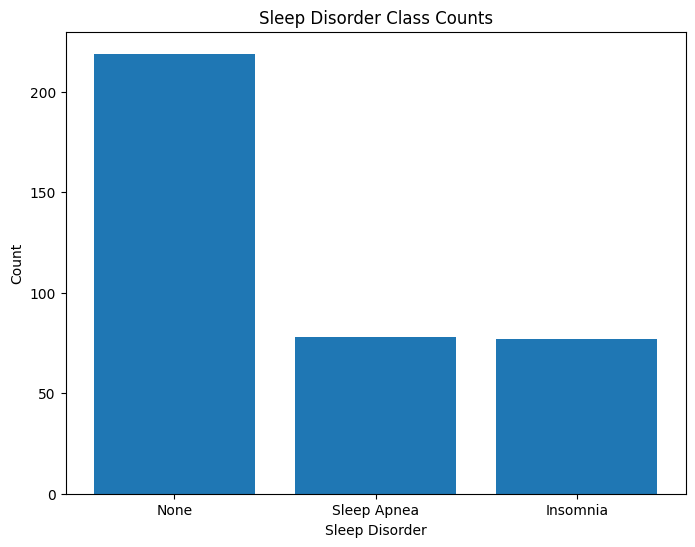

In [8]:
# First check the class (target) is reasonably balanced
# (A big class imbalance would lead to the "1/100 once in a blue moon" problem)

target_counts = df['Sleep Disorder'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(target_counts.index, target_counts.values)
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.title('Sleep Disorder Class Counts')
plt.show()

In [9]:
# Class balance is reasonable: ~219 None, ~78 Sleep Apnea, ~77 Insomnia
# Not perfectly balanced, but close enough to proceed

In [10]:
# The dataset has categorical columns (Gender, Occupation, BMI Category)
# We need to convert these to numbers before feeding them into the classifier
# We also drop Person ID (not a real feature) and Blood Pressure (complex string format)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Occupation'] = le.fit_transform(df['Occupation'])
df['BMI Category'] = le.fit_transform(df['BMI Category'])

In [11]:
# Create X and Y dataframes
X = df.drop(['Person ID', 'Sleep Disorder', 'Blood Pressure'], axis=1)
y = df['Sleep Disorder']

Text(0.5, 1.0, 'Stress Level vs Sleep Duration (colored by Sleep Disorder)')

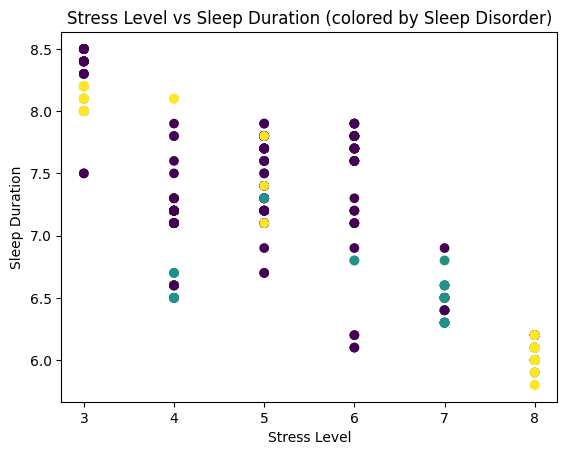

In [12]:
# Just to get a feel for the problem, let's try guessing two features
# that might separate the classes. At this stage this is just a wild guess!
plt.scatter(df['Stress Level'], df['Sleep Duration'], c=df['Sleep Disorder'].map({'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}))
plt.xlabel('Stress Level')
plt.ylabel('Sleep Duration')
plt.title('Stress Level vs Sleep Duration (colored by Sleep Disorder)')

In [13]:
# Let's try another pair since a lot fo the classes overlap

Text(0.5, 1.0, 'Age vs Physical Activity Level (colored by Sleep Disorder)')

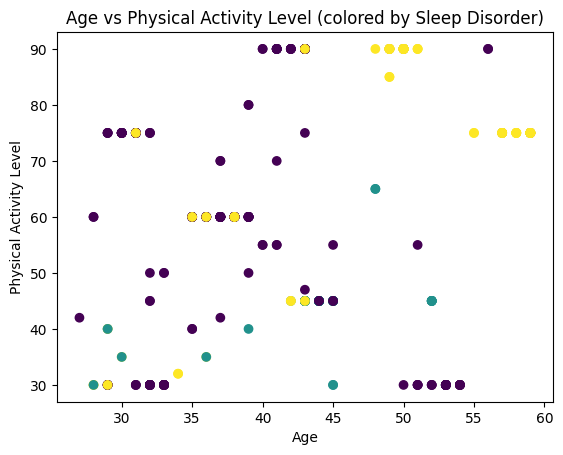

In [14]:
plt.scatter(df['Age'], df['Physical Activity Level'], c=df['Sleep Disorder'].map({'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}))
plt.xlabel('Age')
plt.ylabel('Physical Activity Level')
plt.title('Age vs Physical Activity Level (colored by Sleep Disorder)')

In [15]:
# Let's train a Random Forest classifier then get it to tell us

In [16]:
# Split data into training and testing sets (remove random_state parameter)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize and train a Random Forest Classifier
# n_estimators = number of decision trees
n_estimators = 50
rf_classifier = RandomForestClassifier(n_estimators=n_estimators)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [18]:
# We now have n_estimators=50 decision trees all grouped together into a random "forest"
# Unlike a single decision tree, we cannot print the whole forest,
# but we can print out the individual trees

In [19]:
# Print out the first estimator tree
from sklearn.tree import export_text

tree_rules = export_text(rf_classifier.estimators_[0], feature_names=X.columns)
print(tree_rules)

|--- Daily Steps <= 9000.00
|   |--- Sleep Duration <= 6.95
|   |   |--- Age <= 35.50
|   |   |   |--- Age <= 30.50
|   |   |   |   |--- Quality of Sleep <= 5.50
|   |   |   |   |   |--- Daily Steps <= 4050.00
|   |   |   |   |   |   |--- Heart Rate <= 82.50
|   |   |   |   |   |   |   |--- class: 2.0
|   |   |   |   |   |   |--- Heart Rate >  82.50
|   |   |   |   |   |   |   |--- Occupation <= 7.50
|   |   |   |   |   |   |   |   |--- class: 2.0
|   |   |   |   |   |   |   |--- Occupation >  7.50
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- Daily Steps >  4050.00
|   |   |   |   |   |   |--- class: 2.0
|   |   |   |   |--- Quality of Sleep >  5.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- Age >  30.50
|   |   |   |   |--- Age <= 33.50
|   |   |   |   |   |--- Sleep Duration <= 6.05
|   |   |   |   |   |   |--- Age <= 32.50
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- Age >  32.50
|   |   |   |   |   |   |   |--- class

In [20]:
# Calculate the predictions from the test data
# The .predict calls all of the decision trees one by one, then takes the majority class as the output
y_pred = rf_classifier.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8933333333333333


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(cm)

[[13  1  2]
 [ 0 46  3]
 [ 1  1  8]]


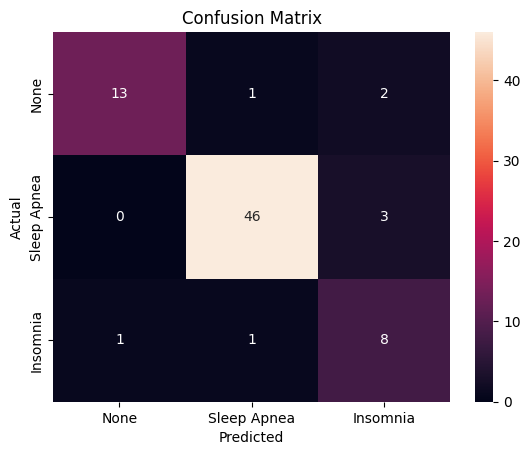

In [22]:
# Plot the confusion matrix as a heat map using seaborn
sns.heatmap(cm, annot=True, xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
# Now we can use the trained model to make predictions on new data
# This is why we did this in the first place!

# Example: Male (0), Age 35, Occupation=Engineer (encoded), Sleep Duration=6.5,
# Quality of Sleep=5, Physical Activity=40, Stress Level=7,
# BMI Category=Overweight (encoded), Heart Rate=80, Daily Steps=4000
new_data = [0, 35, 2, 6.5, 5, 40, 7, 3, 80, 4000]

rf_classifier.predict([new_data])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array(['Insomnia'], dtype=object)

In [24]:
# But do we really need all 10 features?
# Surely not all features have the same weighting in predicting sleep disorders
# Let's use .feature_importances_ to find out which ones matter most!

In [25]:
rf_classifier.feature_importances_

array([0.01252732, 0.14339382, 0.12534573, 0.12756442, 0.0417457 ,
       0.10858352, 0.03877352, 0.24219346, 0.10265122, 0.0572213 ])

In [26]:
rf_classifier.feature_names_in_

array(['Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps'], dtype=object)

Text(0.5, 1.0, 'Feature Importances for Sleep Disorder Prediction')

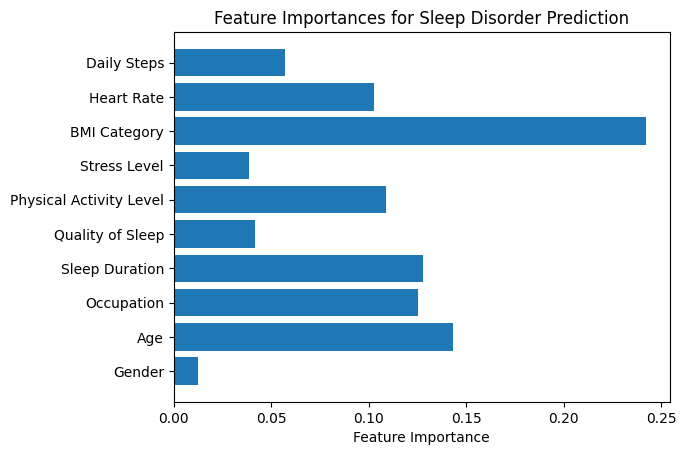

In [27]:
# Pretty hard to interpret the raw numbers - let's plot a graph
plt.barh(rf_classifier.feature_names_in_, rf_classifier.feature_importances_)
plt.xlabel('Feature Importance')
plt.title('Feature Importances for Sleep Disorder Prediction')